<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_OB_WEEK02_Text_Analytics_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **4. 텍스트 분류 실습 - 20 뉴스 그룹 분류**

- 텍스트를 피처 벡터화로 변환하면 일반적으로 희소 행렬 형태가 됨
- 이러한 희소행렬에 분류를 효과적으로 잘 처리할 수 있는 알고리즘
  - 로지스틱 회귀, 선형 서포트 벡터 머신, 나이브 베이즈 등

## 텍스트 정규화

In [2]:
!rm -rf /root/scikit_learn_data

In [3]:
# fetch_20newsgroups(): 인터넷에서 로컬 컴퓨터로 데이터를 먼저 내려받은 후 메모리로 데이터 로딩

from sklearn.datasets import fetch_20newsgroups

news_data=fetch_20newsgroups(subset='all',random_state=156)

In [4]:
# 어떤 key 값을 가지고 있는지 확인
print(news_data.keys())

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])


In [5]:
# Target 클래스가 어떻게 구성돼 있는지 확인
import pandas as pd

print('target 클래스의 값과 분포도 \n', pd.Series(news_data.target).value_counts().sort_index())
print('target 클래스의 이름들 \n', news_data.target_names)

target 클래스의 값과 분포도 
 0     799
1     973
2     985
3     982
4     963
5     988
6     975
7     990
8     996
9     994
10    999
11    991
12    984
13    990
14    987
15    997
16    910
17    940
18    775
19    628
Name: count, dtype: int64
target 클래스의 이름들 
 ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


- Target = 문서의 주제
- Target class = 각 뉴스 글이 어떤 주제의 뉴스 그룹에 속하는지를 나타내는 카테고리 라벨
- Target names = 각 숫자가 어떤 주제인지 알려주는 것

In [7]:
# 개별 데이터 한 개만 추출해 개별 데이터가 텍스트로 어떻게 구성돼 있는지 확인
print(news_data.data[0])

From: egreen@east.sun.com (Ed Green - Pixel Cruncher)
Subject: Re: Observation re: helmets
Organization: Sun Microsystems, RTP, NC
Lines: 21
Distribution: world
Reply-To: egreen@east.sun.com
NNTP-Posting-Host: laser.east.sun.com

In article 211353@mavenry.altcit.eskimo.com, maven@mavenry.altcit.eskimo.com (Norman Hamer) writes:
> 
> The question for the day is re: passenger helmets, if you don't know for 
>certain who's gonna ride with you (like say you meet them at a .... church 
>meeting, yeah, that's the ticket)... What are some guidelines? Should I just 
>pick up another shoei in my size to have a backup helmet (XL), or should I 
>maybe get an inexpensive one of a smaller size to accomodate my likely 
>passenger? 

If your primary concern is protecting the passenger in the event of a
crash, have him or her fitted for a helmet that is their size.  If your
primary concern is complying with stupid helmet laws, carry a real big
spare (you can put a big or small head in a big helmet, bu

- 위 데이터를 보면, 뉴스그룹 기사의 내용 뿐만 아니라 뉴스 그룹 제못, 작성자, 소속, 이메일 등의 다양한 정보를 가지고 있음
- 이 중 내용을 제외하고 제목 등의 다른 정보는 제거
  - 제목과 소속, 이메일 주소 등의 헤더와 푸터 정보들은 뉴스그룹 분류의 Target 클래스 값과 유사한 데이터를 가지고 있는 경우가 많기 때문
  - 이를 포함하게 되면 대부분의 ML 알고리즘을 적용해도 상당히 높은 예측 성능을 나타냄
  - 순수한 텍스트만으로 구성된 기사 내용으로 어떤 뉴스 그룹에 속하는지 분류하고자 하기에 삭제
- remove 파라미터를 이용하면 뉴스그룹 기사의 헤더(header), 푸터(footer) 등 제거 가능
- fetch_20newsgroups()는 subset 파라미터를 이용해 학습 데이터 세트와 테스트 데이터 세트를 분리해 내려받을 수 있음

In [8]:
from sklearn.datasets import fetch_20newsgroups

# subset='train'으로 학습용 데이터만 추출, remove=('headers', 'footers', 'quotes')로 내용만 추출
train_news = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'),
                                random_state=156)
X_train = train_news.data
y_train = train_news.target

# subset='test'으로 테스트 데이터만 추출, remove=('headers', 'footers', 'quotes')로 내용만 추출
test_news = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'),
                               random_state=156)
X_test = test_news.data
y_test = test_news.target
print('학습 데이터 크기 {0}, 테스트 데이터 크기 {1}'.format(len(train_news.data), len(test_news.data)))

학습 데이터 크기 11314, 테스트 데이터 크기 7532


## 피처 벡터화 변환과 머신러닝 모델 학습/예측/평가

- CountVectorizer를 이용해 학습 데이터와 테스트 데이터의 텍스트를 피처 벡터화
- 반드시 유의해야 할 점
  1. 테스트 데이터에서 CountVectorizer를 적용할 때는 반드시 학습 데이터를 이용해 fit()이 수행된 CountVectorizer 객체를 이용해 테스트 데이터를 변환(transform)
      - 그래야만 학습 시 설정된 CountVectorizer의 피처 개수와 테스트 데이터를 CountVectorizer로 변환할 피처 개수가 같아짐
  2. 테스트 데이터의 피처 벡터화 시, fit_transform()을 사용하면 안 됨
      - CountVectorizer.fit_transform(테스트 데이터)을 테스트 데이터 세트에 적용하면, 테스트 데이터 기반으로 다시 CountVectorizer가 fit()을 수행하고 transform( )하기 때문에 학습 시 사용된 피처 개수와 예측 시 사용할 피처 개수가 달라짐

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Count Vectorization으로 피처 벡터화 변환 수행
cnt_vect = CountVectorizer()
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect.transform(X_train)

# 학습 데이터로 fit()된 CountVectorizer를 이용해 테스트 데이터를 피터 벡터화 변환 수행
X_test_cnt_vect = cnt_vect.transform(X_test)

print('학습 데이터 텍스트의 VountVectorizer Shape:', X_train_cnt_vect.shape)

학습 데이터 텍스트의 VountVectorizer Shape: (11314, 101631)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# LogisticRegression을 이용하여 학습/예측/평가 수행
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_cnt_vect, y_train)
pred = lr_clf.predict(X_test_cnt_vect)
print('CountVectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

CountVectorized Logistic Regression의 예측 정확도는 0.617


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터화를 적용해 학습 데이터 세트와 테스트 데이터 세트 변환
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

# LogisticRegression을 이용해 학습/예측/평가 수행
lr_clf = LogisticRegression(solver = 'liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Logistic Regression의 예측 정확도는 0.678


- TF-IDF가 단순 카운트 기반보다 훨씬 높은 예측 정확도를 제공
- 일반적으로 문서 내에 텍스트가 많고 많은 문서를 가지는 텍스트 분석에서 카운트 벡터화보다는 TF-IDF 벡터화가 좋은 예측 결과를 도출

In [12]:
# TfidfVectorizer 클래스의 스톱 워드를 기존 'None'에서 'english'로 변경
# ngram range는 기존 (1,1)에서 (1,2)로, max_df=300으로 변경한 뒤 다시 예측 성능 측정
tfidf_vect = TfidfVectorizer(stop_words = 'english', ngram_range = (1, 2), max_df = 300)
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

lr_clf = LogisticRegression(solver = 'liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Vectorized Logistic Regression의 예측 정확도는 0.690


In [13]:
# GridSearchCV를 이용해 로지스틱 회귀의 하이퍼 파라미터 최적화 수행

from sklearn.model_selection import GridSearchCV

# C 파라미터만 변경하면서 최적의 C값을 찾고 이 C값으로 학습된 모델에서 테스트 데이터로 예측해 성능 평가
# 최적 C 값 도출 튜닝 수행. CV는 3 폴드 세트로 설정
params = {'C':[0.01, 0.1, 1, 5, 10]}
grid_cv_lr = GridSearchCV(lr_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_lr.fit(X_train_tfidf_vect, y_train)
print('Logistic Regression best C parameter:', grid_cv_lr.best_params_)

# 최적 C 값으로 학습된 grid_cv로 예측 및 정확도 평가
pred = grid_cv_lr.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Logistic Regression best C parameter: {'C': 10}
TF-IDF Vectorized Logistic Regression의 예측 정확도는 0.704


## 사이킷런 파이프라인(Pipeine) 사용 및 GridSearchCV와의 결합

In [14]:
import os
from sklearn.pipeline import Pipeline

# pipeline 객체 선언
pipeline = Pipeline([('tfidf_vect', TfidfVectorizer(stop_words='english')),
                     ('lr_clf', LogisticRegression(random_state=156))])

- TfidfVectorizer 객체를 tfid_vect라는 객체 변수명으로, LogisticRegression 객체를 lr_clf라는 객체 변수명으로 생성
- 이 두 개의 객체를 파이프라인으로 연결하는 Pipeine 객체 pipeline을 생성한다는 의미

In [15]:
from sklearn.pipeline import Pipeline

# TfidfVectorizer 객체를 tfidf_vect로, LogisticRegression 객체를 lr_clf로 생성하는 Pipeline 생성
pipeline = Pipeline([('tfidf_vect', TfidfVectorizer(stop_words = 'english', ngram_range = (1, 2), max_df = 300)),
                     ('lr_clf', LogisticRegression(solver = 'liblinear', C=10))])

# 별도의 TfidfVectorizer 객체의 fit(), transform()과 LogisticRegression의 fit(), predict()가 필요없음
# pipeline의 fit()과 predict() 만으로 한꺼번에 피처 벡터화와 ML 학습/예측 가능
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
print('Pipeline을 통한 Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Pipeline을 통한 Logistic Regression의 예측 정확도는 0.704


- 아래는 GridSearchCV에 Pipeline을 입력하면서 TfidfVectorizer의 파라미터와 LogisticRegression의 하이퍼 파라미터를 함께 최적화하는 코드
- 아래 코드를 보면, GridSearchCV에 Estimator가 아닌 Pipeline을 입력할 경우, param_grid의 입력값 설정이 기존과 약간 다름
  - 딕셔너리 형태의 Key와 Value 값을 가지며, Value를 리스트 형태로 입력하는 것은 동일
  - 다만 Key 값을 살펴보면 'tfidf_vect__ngram_range'와 같이 하이퍼 파라미터명이 객체 변수명과 결합돼 제공
    - Pipeline을 GridSearchCV에 인자로 입력하면 GridSearchCV는 Pipeline을 구성하는 피처 벡터화 객체의 파라미터와 Estimator 객체의 하이퍼 파라미터를 각각 구별할 수 있어야 하는데,
    - 이때 개별 객체 명과 파라미터명/하이퍼 파라미터명을 결합해 Key 값으로 할당하는 것

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('tfidf_vect', TfidfVectorizer(stop_words='english')),
                     ('lr_clf', LogisticRegression())])

# Pipeline에 기술된 각각의 객체 변수에 언더바(_) 2개를 연달아 붙여 GridSearchCV에 사용될
# 파라미터/하이퍼 파라미터 이름과 값을 설정
params = {'tfidf_vect__ngram_range':[(1, 1), (1, 2), (1, 3)],
          'tfidf_vect__max_df':[100, 300, 700],
          'lr_clf__C':[1, 5, 10]}

# GridSearchCV의 생성자에 Estimator가 아닌 Pipeline 객체 입력
grid_cv_pipe = GridSearchCV(pipeline, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_pipe.fit(X_train, y_train)
print(grid_cv_pipe.best_params_, grid_cv_pipe.best_score_)

pred = grid_cv_pipe.predict(X_test)
print('Pipeline을 통한 Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

- TfidfVectorizer 객체의 max_df 파라미터가 700, ngramjrange 파라미터가 (1,2)로 피처 벡터화된 데이터 세트에 LogisticRegression의 C 하이퍼 파라미터에 10을 적용해 예측 분류를 수행할 때 가장 좋은 검증 세트 성능 수치

# **5. 감성 분석**

- Sentiment Analysis
- 문서의 주관적인 감성, 의견, 감정, 기분 등을 파악하기 위한 방법
- 문서 내 텍스트가 나타내는 여러가지 주관적 단어와 문맥을 기반으로 감성 수치를 계산
- 이 감성 지수는 긍정 감성 지수와 부정 감성 지수로 구성되며 이를 합산해 긍정 감성 또는 부정 감성 결정
- 방식
  - 지도학습 : 학습데이터와 타깃 레이블 값을 기반으로 감성 분석 학습을 수행한 뒤 이를 기반으로 다른 데이터의 감성 분석 예측
  - 비지도학습 : 'Lexicon'이라는 일종의 감성 어휘 사전 이용 (이 사전은 감성 분석을 위한 용어와 문맥에 대한 다양한 정보를 가지고 있어 문서의 긍, 부정적 감성 여부 판단)

# 지도학습 기반 감성 분석 실습 - IMDB 영화평

데이터
- id : 각데이터의 id
- sentiment : 영화평(review)의 Sentiment 결과 값(Target Label)
  - 1은 긍정적 평가, 0은 부정적 평가를 의미
- review : 영화평의 텍스트

In [19]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

review_df = pd.read_csv('/content/drive/MyDrive/ESAA/labeledTrainData.tsv', header=0, sep="\t", quoting=3)
review_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."


In [20]:
# 텍스트 구성 확인
print(review_df['review'][0])

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

< 정규 표현식 >
- [^a-zA-Z] : 영어 대, 소문자가 아닌 모든 문자를 찾는 것
- re.sub("[^a-zA-Z]", " ", x) : 영어 대, 소문자가 아닌 모든 문자를 찾아서 공란으로 변경

In [21]:
import re   # 정규 표현식 지원

# <br> html 태그는 replace 함수로 공백으로 변환
review_df['review'] = review_df['review'].str.replace('<br />', ' ')

# 파이썬의 정규 표현식 모듈인 re를 이용해 영어 문자열이 아닌 문자는 모두 공백으로 변환
review_df['review'] = review_df['review'].apply(lambda x : re.sub("[^a-zA-Z]", " ", x))

In [22]:
from sklearn.model_selection import train_test_split

# 결정 값 클래스인 sentiment 칼럼을 추출해 결정 값 데이터셋 제작
# 원본에서 id와 sentiment 칼럼을 삭제하여 피처 데이터셋 생성
class_df = review_df['sentiment']
feature_df = review_df.drop(['id', 'sentiment'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(feature_df, class_df, test_size=0.3, random_state=156)

X_train.shape, X_test.shape

((17500, 1), (7500, 1))

In [23]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# stop word는 English, ngram은 (1, 2)로 설정해 CountVectorization 수행
# LogisticRegression의 C는 10으로 설정
pipeline = Pipeline([('cnt_vect', CountVectorizer(stop_words='english', ngram_range=(1, 2))),
                     ('lr_clf', LogisticRegression(solver='liblinear', C=10))])

# Pipeline 객체를 이용해 fit(), predict()로 학습/예측 수행. predict_proba()는 roc_auc 때문에 수행
pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1]

print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도는 0.8861, ROC-AUC는 0.9503


In [24]:
# TF-IDF 벡터화 수행
pipeline = Pipeline([('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
                     ('lr_clf', LogisticRegression(solver = 'liblinear', C=10))])

pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1]

print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도는 0.8936, ROC-AUC는 0.9598


## 비지도학습 기반 감성 분석 소개

- 비지도 감성 분석은 Lexicon을 기반으로 하는 것
- 위의 지도 감성 분석은 데이터 세트가 레이블 값을 가지고 있었지만 많은 감성 분석용 데이터는 이러한 결정된 레이블 값을 가지고 있지 않음
  - 이러한 경우에 Lexicon(= 감성 사전) 유용
  - 감성 사전은 긍부정의 수치를 가지고 있고 이를 감성 지수라고 함
  - 감성 지수는 단어의 위치, 주변 단어, 문맥, POS(Part of Speech) 등을 참고해 결정됨
  - 이 감성 사전을 구현한 것 = NLTK 패키지

< NLTK 패키지 >
- NLTK에서 제공하는 WordNet 모듈 = 방대한 영어 어휘 사전
- Wordnet은 단순한 어휘 사전이 아닌 시맨틱 분석을 제공하는 어휘 사전
  - semantic
    - 문맥상의 의미
    - 다양한 상황에서 같은 어휘라도 다르게 사용되는 어휘의 시맨틱 정보를 제공
    - 이를 위해 각각의 품사로 구성된 개별 단어를 Synet(Sets of cognitive synonymos)이라는 개념을 이용해 표현
- but! 실제 업무는 성능이 더 좋은 다른 감성 사전 적용
  - SentiWordNet
    - WordNet의 Synset 개념을 감성 분석에 적용한 것
    - 긍정 감성 지수, 부정 감성 지수, 객관성 지수를 Synset 별로 할당
  - VADER
    - 주로 소셜미디어의 텍스트에 대한 감성 분석 제공을 위한 패키지
    - 대용량 텍스트 데이터에 잘 사용

### SentiWordNet을 이용한 감성 분석

**WordNet Synset과F SentiWordNet SentiSynset 클래스의 이해**

In [25]:
# NLTK의 모든 데이터 세트와 패키지 내려받기
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [26]:
# WordNet 모듈 import
from nltk.corpus import wordnet as wn

term = 'present'

# 'present'라는 단어로 wordnet의 synsets 생성
synsets = wn.synsets(term)
print('synsets() 반환 type:', type(synsets))
print('synsets() 반환 값 개수:', len(synsets))
print('synsets() 반환 값:', synsets)

synsets() 반환 type: <class 'list'>
synsets() 반환 값 개수: 18
synsets() 반환 값: [Synset('present.n.01'), Synset('present.n.02'), Synset('present.n.03'), Synset('show.v.01'), Synset('present.v.02'), Synset('stage.v.01'), Synset('present.v.04'), Synset('present.v.05'), Synset('award.v.01'), Synset('give.v.08'), Synset('deliver.v.01'), Synset('introduce.v.01'), Synset('portray.v.04'), Synset('confront.v.03'), Synset('present.v.12'), Synset('salute.v.06'), Synset('present.a.01'), Synset('present.a.02')]


- Synset 객체의 파라미터 'present.n.01' = POS 태그
  - 'present.n.01'에서 present는 의미
  - n은 명사품사
  - 01은 present가 명사로서 가지는 의미가 여러가지 있어서 이를 구분하는 인덱스

In [27]:
# synset 객체가 가지는 여러 가지 속성
for synset in synsets:
  print('##### Synset name:', synset.name(), ' #####')
  print('POS:', synset.lexname())
  print('Definition:', synset.definition())
  print('Lemmas:', synset.lemma_names())

##### Synset name: present.n.01  #####
POS: noun.time
Definition: the period of time that is happening now; any continuous stretch of time including the moment of speech
Lemmas: ['present', 'nowadays']
##### Synset name: present.n.02  #####
POS: noun.possession
Definition: something presented as a gift
Lemmas: ['present']
##### Synset name: present.n.03  #####
POS: noun.communication
Definition: a verb tense that expresses actions or states at the time of speaking
Lemmas: ['present', 'present_tense']
##### Synset name: show.v.01  #####
POS: verb.perception
Definition: give an exhibition of to an interested audience
Lemmas: ['show', 'demo', 'exhibit', 'present', 'demonstrate']
##### Synset name: present.v.02  #####
POS: verb.communication
Definition: bring forward and present to the mind
Lemmas: ['present', 'represent', 'lay_out']
##### Synset name: stage.v.01  #####
POS: verb.creation
Definition: perform (a play), especially on a stage
Lemmas: ['stage', 'present', 'represent']
##### Sy

< 단어의 상호 유사도 >

- WordNet은 어떤 어휘와 다른 어휘 간의 관계를 유사도로 나타낼 수 있음
- synset 객체는 단어 간의 유사도를 나타내기 위해서 path_similarity( ) 메서드를 제공

In [28]:
# synset 객체를 단어별로 생성
tree = wn.synset('tree.n.01')
lion = wn.synset('lion.n.01')
tiger = wn.synset('tiger.n.02')
cat = wn.synset('cat.n.01')
dog = wn.synset('dog.n.01')

entities = [tree, lion, tiger, cat, dog]
similarities = []
entity_names = [entity.name().split('.')[0] for entity in entities]

# 단어별 synset을 반복하면서 다른 단어의 synset과 유사도를 측정
for entity in entities:
  similarity = [round(entity.path_similarity(compared_entity), 2)
                for compared_entity in entities]
  similarities.append(similarity)

# 개별 단어별 synset과 다른 단어의 synset과의 유사도를 DataFrame 형태로 저장
similarity_df = pd.DataFrame(similarities, columns = entity_names, index = entity_names)
similarity_df

,tree,lion,tiger,cat,dog
tree,1.00,0.07,0.07,0.08,0.12
lion,0.07,1.00,0.33,0.25,0.17
tiger,0.07,0.33,1.00,0.25,0.17
cat,0.08,0.25,0.25,1.00,0.20
dog,0.12,0.17,0.17,0.20,1.00


- SentiWordNet은 WbrdNet의 Synset과 유사한 Senti_Synset 클래스를 가지고 있음
- SentiWordNet 모듈의 Senti_Synsets( )는 WordNet 모듈이라서 synsets( )와 비슷하게 Senti_Synset 클래스를 리스트 형태로 반환

In [29]:
import nltk
from nltk.corpus import sentiwordnet as swn

senti_synsets = list(swn.senti_synsets('slow'))
print('senti_synsets() 반환 type:', type(senti_synsets))
print('senti_synsets() 반환 값 개수:', len(senti_synsets))
print('senti_synsets() 반환 값:', senti_synsets)

senti_synsets() 반환 type: <class 'list'>
senti_synsets() 반환 값 개수: 11
senti_synsets() 반환 값: [SentiSynset('decelerate.v.01'), SentiSynset('slow.v.02'), SentiSynset('slow.v.03'), SentiSynset('slow.a.01'), SentiSynset('slow.a.02'), SentiSynset('dense.s.04'), SentiSynset('slow.a.04'), SentiSynset('boring.s.01'), SentiSynset('dull.s.08'), SentiSynset('slowly.r.01'), SentiSynset('behind.r.03')]


- senti_synsets 객체는 단어의 감성을 나타내는 감성 지수와 객관성을(감성과 반대) 나타내는 객관성 지수를 가지고 있음
- 감성 지수는 다시 긍정 감성 지수와 부정 감성 지수로 나뉨
- 어떤 단어가 전혀 감성적이지 않으면 객관성 지수는 1이 되고, 감성 지수는 모두 0이 됨

In [30]:
father = swn.senti_synset('father.n.01')

print('father 긍정감성 지수:', father.pos_score())
print('father 부정감성 지수:', father.neg_score())
print('father 객관성 지수:', father.obj_score())
print('\n')

fabulous = swn.senti_synset('fabulous.a.01')

print('fabulous 긍정감성 지수:', fabulous.pos_score())
print('fabulous 부정감성 지수:', fabulous.neg_score())

father 긍정감성 지수: 0.0
father 부정감성 지수: 0.0
father 객관성 지수: 1.0


fabulous 긍정감성 지수: 0.875
fabulous 부정감성 지수: 0.125


**SentiWordNet을 이용한 영화 감상평 감성 분석**

< 순서 >
1. 문서(Document)를 문장(Sentence) 단위로 분해
2. 다시 문장을 단어(Word) 단위로 토큰화하고 품사 태깅
3. 품사 태깅된 단어 기반으로 synset 객체와 senti_synset 객체를 생성
4. senti_synset 객체에서 긍정 감성/부정 감성 지수를 구하고 이를 모두 합산해 특정 임계치 값 이상일 때 긍정 감성으로, 그렇지 않을 때는 부정 감성으로 결정

In [31]:
#### 품사 태깅을 수행하는 내부 함수 생성 ####

from nltk.corpus import wordnet as wn

# 간단한 NTLK PennTreebank Tag를 기반으로 WordNet 기반의 품사 Tag로 변환
def penn_to_wn(tag):
  if tag.startswith('J'):
    return wn.ADJ
  elif tag.startswith('N'):
    return wn.NOUN
  elif tag.startswith('R'):
    return wn.ADV
  elif tag.startswith('V'):
    return wn.VERB

- 각 단어의 긍정 감성 지수와 부정 감성 지수를 모두 합한 총 감성 지수가 0 이상일 경우 긍정 감성, 그렇지 않을 경우 부정 감성으로 예측

In [32]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import sentiwordnet as swn
from nltk import sent_tokenize, word_tokenize, pos_tag

def swn_polarity(text):
  # 감성 지수 초기화
  sentiment = 0.0
  tokens_count = 0

  lemmatizer = WordNetLemmatizer()   # 표제어 추출 > 단어를 원형으로 변환
  raw_sentences = sent_tokenize(text)
  # 분해된 문장별로 단어 토큰 -> 품사 태깅 후에 SentiSynset 생성 -> 감성 지수 합산
  for raw_sentence in raw_sentences:
    # NLTK 기반의 품사 태깅 문자 추출
    tagged_sentence = pos_tag(word_tokenize(raw_sentence))
    for word, tag in tagged_sentence:

      # WordNet 기반 품사 태깅과 어근 추출
      wn_tag = penn_to_wn(tag)
      if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
        continue
      lemma = lemmatizer.lemmatize(word, pos=wn_tag)
      if not lemma:
        continue

      # 어근을 추출한 단어와 WordNet 기반 품사 태깅을 입력해 Synset 객체를 생성
      synsets = wn.synsets(lemma, pos=wn_tag)
      if not synsets:
        continue
      # sentiwordnet의 감성 단어 분석으로 감성 synset 추출
      # 모든 단어에 대해 긍정 감성 지수는 +로 부정 감성 지수는 -로 합산해 감성 지수 계산
      synset = synsets[0]
      swn_synset = swn.senti_synset(synset.name())
      sentiment += (swn_synset.pos_score() - swn_synset.neg_score())
      tokens_count += 1

  if not tokens_count:
    return 0

  # 총 score가 0 이상일 경우 긍정(Positive) 1, 그렇지 않을 경우 부정(Negative) 0 반환
  if sentiment >= 0:
    return 1

  return 0

- 이렇게 생성한 swn_polarity(text) 함수를 IMDB 감상평의 개별 문서에 적용해 긍정 및 부정 감성을 예측
- 판다스의 apply lambda 구문을 이용해 swn_polarity(text)를 개별 감상평 텍스트에 적용
- 지도학습 기반의 감성 분석에서 생성한 review_df DataFrame을 그대로 이용
- review_df의 새로운 칼럼으로 'preds'를 추가해 이 칼럼에 swn_polarity(text)로 반환된 감성 평가를 담고 실제 감성 평가인 'sentiment' 칼럼과 swn_polarity(text)로 반환된 결과의 정확도, 정밀도, 재현율 값을 모두 측정

In [33]:
review_df['preds'] = review_df['review'].apply(lambda x : swn_polarity(x))
y_target = review_df['sentiment'].values
preds = review_df['preds'].values

In [34]:
# SentiWordNet의 감성 분석 예측 성능 살펴보기
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import numpy as np

print(confusion_matrix(y_target, preds))
print("정확도:", np.round(accuracy_score(y_target, preds), 4))
print("정밀도:", np.round(precision_score(y_target, preds), 4))
print("재현율:", np.round(recall_score(y_target, preds), 4))

[[7669 4831]
 [3635 8865]]
정확도: 0.6614
정밀도: 0.6473
재현율: 0.7092


### VADER를 이용한 감성분석

- VADER는 소셜 미디어의 감성 분석 용도로 만들어진 룰 기반의 Lexicon
- VADER는 SentimentlntensityAnalyzer 클래스를 이용해 쉽게 감성 분석을 제공

In [35]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

senti_analyzer = SentimentIntensityAnalyzer()
senti_scores = senti_analyzer.polarity_scores(review_df['review'][0])
print(senti_scores)

{'neg': 0.13, 'neu': 0.743, 'pos': 0.127, 'compound': -0.7943}


- SentimentlntensityAnalyzer 객체를 생성한 뒤, 문서별로 polarity_scores() 메서드를 호출해 감성 점수를 구함
  - 해당 문서의 감성 점수가 특정 임계값 이상이면 긍정, 그렇지 않으면 부정으로 판단
  - Sentimentintensity Analyzer 객체의 polarity_scores() 메서드는 딕셔너리 형태의 감성 점수를 반환
    - 'neg'는 부정 감성 지수, 'neu'는 중립적인 감성 지수, 'pos'는 긍정 감성 지수, compound는 neg, neu, pos score를 적절히 조합해 —1에서 1 사이의 감성 지수를 표현한 값
    - compound score를 기반으로 부정 감성 또는 긍정 감성 여부를 결정
    - 보통 0.1 이상이면 긍정 감성, 그 이하이면 부정 감성으로 판단하나, 상황에 따라 이 임계값을 적절히 조정해 예측 성능을 조절

In [ ]:
# VADER를 이용해 IMDB의 감성 분석 수행
## 입력 파라미터로 영화 감상평 텍스트와 긍정/부정을 결정하는 임곗값(threshold)을 가지고,
## SentimentlntensityAnalyzer 객체의 polarity_scores( ) 메서드를 호출해 감성 결과를 반환
def vader_polarity(review, threshold = 0.1):
  analyzer = SentimentIntensityAnalyzer()
  scores = analyzer.polarity_scores(review)

  # compound 값에 기반해 threshold 입력값보다 크면 1, 그렇지 않으면 0을 반환
  agg_score = scores['compound']
  final_sentiment = 1 if agg_score >= threshold else 0
  return final_sentiment

# apply lambda 식을 이용해 레코드별로 vader_polarity()를 수행하고 결과를 'vader_preds'에 저장
review_df['vader_preds'] = review_df['review'].apply(lambda x : vader_polarity(x, 0.1))
y_target = review_df['sentiment'].values
vader_preds = review_df['vader_preds'].values

print(confusion_matrix(y_target, vader_preds))
print('정확도:', np.round(accuracy_score(y_target, vader_preds), 4))
print('정밀도:', np.round(precision_score(y_target, vader_preds), 4))
print('재현율:', np.round(recall_score(y_target, vader_preds), 4))

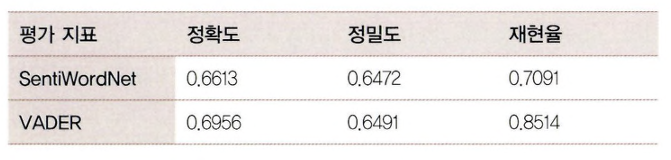